# Linear Regression on Network Traffic

In this hands-on assignment, we will explore learn models, in particular linear regression. Linear models can work well when there is a linear relationship between the target variable being predicted and the input features. In other words, when the target prediction can be modeled as a linear combination of the input features, linear models may be appropriate.

We'll explore the relationship beween bytes and packets in this hands-on, which may have a linear relationship at times. We will also explore how basis expansion---in particular polynomial basis expansion---can allow linear regression to fit more complex relationships between features and targets.

In [1]:
# Machine Learning Libraries
import numpy as np
import pandas as pd
from sklearn import linear_model

import logging
logging.getLogger("scapy.runtime").setLevel(logging.ERROR)

import sys
sys.path.insert(1,"/Users/feamster/research/netml/src/")
from netml.pparser.parser import PCAP
from netml.utils.tool import dump_data, load_data

# Plotting Library
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.figsize"] = (8,6)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/chris/Library/Python/3.11/lib/python/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/homebrew/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/chris/Library/Python/3.11/lib/python/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/Users/c

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/chris/Library/Python/3.11/lib/python/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/homebrew/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/chris/Library/Python/3.11/lib/python/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/Users/c

AttributeError: _ARRAY_API not found

/opt/homebrew/lib/python3.11/site-packages/scapy/layers/ipsec.py:512: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  cipher=algorithms.TripleDES,
/opt/homebrew/lib/python3.11/site-packages/scapy/layers/ipsec.py:516: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  cipher=algorithms.TripleDES,



## Part 1: Simple Linear Regression.

### Group Traffic Info Flows 

This example below uses a packet capture that is provided in the repository. You are also welcome (and encouraged!) to capture your own traffic.

Use `netml` to load the pcap and convert packets to flows, using pcap2flows.

In [2]:
hpcap = PCAP('data/http.pcap', flow_ptks_thres=2, verbose=10)
hpcap.pcap2flows()
len(hpcap.flows)

pcap_file: data/http.pcap
ith_packets: 0


ith_packets: 10000


ith_packets: 20000


len(flows): 593
total number of flows: 593. Num of flows < 2 pkts: 300, and >=2 pkts: 293 without timeout splitting.
kept flows: 293. Each of them has at least 2 pkts after timeout splitting.
flow_durations.shape: (293, 1)
        col_0
count 293.000
mean   11.629
std    15.820
min     0.000
25%     0.076
50%     0.455
75%    20.097
max    46.235
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   col_0   293 non-null    float64
dtypes: float64(1)
memory usage: 2.4 KB
None
0th_flow: len(pkts): 4
After splitting flows, the number of subflows: 291 and each of them has at least 2 packets.


291

### Generate Features

Use the `netml` "STATS" option to generate features for each flow, which will provide the following features for each flow:

0. Duration
1. Packets per second
2. Bytes per second
3. Mean packet size
4. Standard deviation of packet sizes
5. 25th, median, 75th, min, max packet sizes

The exercise below requires a [slight modification](https://github.com/chicago-cdac/netml/pull/16/commits/79c0f930f2882c7bf042a9eb45e2a6ac413a695d) to the `netml` library (for versions <= 0.2.1) to add two additional features:
* number of packets per flow
* number of bytes per flow

You can modify the library (line 455 of `parser.py`) to add total number of packets and bytes per flow, or optionally explore the relationships between some of the other features.

In [3]:
# netml >= 0.7 already reports number of packets and number of bytes per flow
# (the last two columns of STATS), so no modification to the library is needed here.
hpcap.flow2features('STATS', fft=False, header=False)

stats_cols = ['duration', 'pkts_rate', 'bytes_rate',
              'mean_pkt_size', 'std_pkt_size',
              'q1_pkt_size', 'median_pkt_size', 'q3_pkt_size',
              'min_pkt_size', 'max_pkt_size',
              'num_pkts', 'num_bytes']

features = pd.DataFrame(hpcap.features, columns=stats_cols)
print(features.shape)
features.head()

True
(291, 12)


,duration,pkts_rate,bytes_rate,mean_pkt_size,std_pkt_size,q1_pkt_size,median_pkt_size,q3_pkt_size,min_pkt_size,max_pkt_size,num_pkts,num_bytes
0,30.076,0.133,11.637,87.500,21.500,66.000,87.500,109.000,66.000,109.000,4.000,350.000
1,30.060,0.133,11.444,86.000,20.000,66.000,86.000,106.000,66.000,106.000,4.000,344.000
2,40.960,0.122,8.057,66.000,0.000,66.000,66.000,66.000,66.000,66.000,5.000,330.000
3,40.962,0.122,8.056,66.000,0.000,66.000,66.000,66.000,66.000,66.000,5.000,330.000
4,0.058,34.661,2738.204,79.000,13.000,72.500,79.000,85.500,66.000,92.000,2.000,158.000


### Train Model

Explore the relationship between some of these features. A natural one to explore is the relationship between the number of bytes in a flow and the number of packets in a flow.

       num_pkts   num_bytes
count   291.000     291.000
mean     84.165  100124.914
std     355.977  517703.464
min       2.000     120.000
25%       6.000     945.000
50%      11.000    2053.000
75%      16.500    6134.000
max    2985.000 4464796.000

correlation: 0.9951


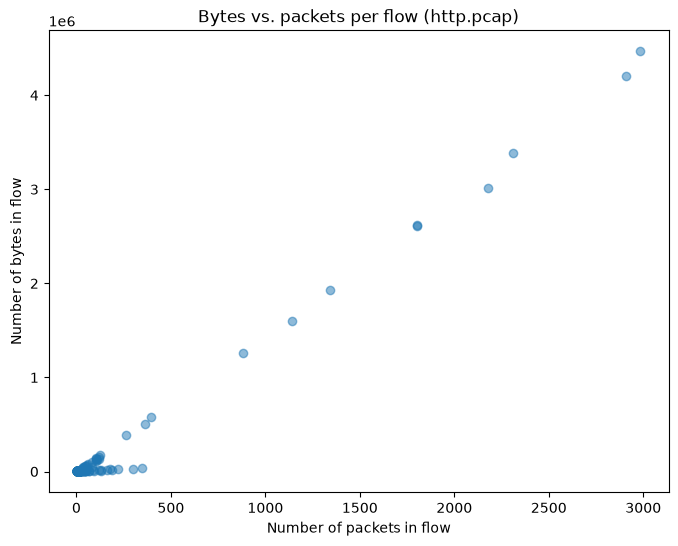

In [4]:
# Bytes per flow should grow roughly linearly with packets per flow,
# since every packet contributes some number of bytes.
print(features[['num_pkts', 'num_bytes']].describe())
print('\ncorrelation:', features['num_pkts'].corr(features['num_bytes']).round(4))

plt.scatter(features['num_pkts'], features['num_bytes'], alpha=0.5)
plt.xlabel('Number of packets in flow')
plt.ylabel('Number of bytes in flow')
plt.title('Bytes vs. packets per flow (http.pcap)')
plt.show()

Train a `Linear Regression` model from scikit learn to model this relationship, and output the resulting predictions into a vector `y_hat`.

In [5]:
# X must be 2-D for scikit-learn; y is the target we want to predict.
X = features[['num_pkts']].values
y = features['num_bytes'].values

model = linear_model.LinearRegression()
model.fit(X, y)

y_hat = model.predict(X)

print(f'intercept: {model.intercept_:.2f} bytes')
print(f'slope:     {model.coef_[0]:.2f} bytes per packet')

intercept: -21680.35 bytes
slope:     1447.22 bytes per packet


### Visualize Your Model

Plot the relationship that your model has learned, by plotting the learned model (which should be a line), along with the points.  Label your axes!

What do you notice about the relationship, and how it relates to the original points?

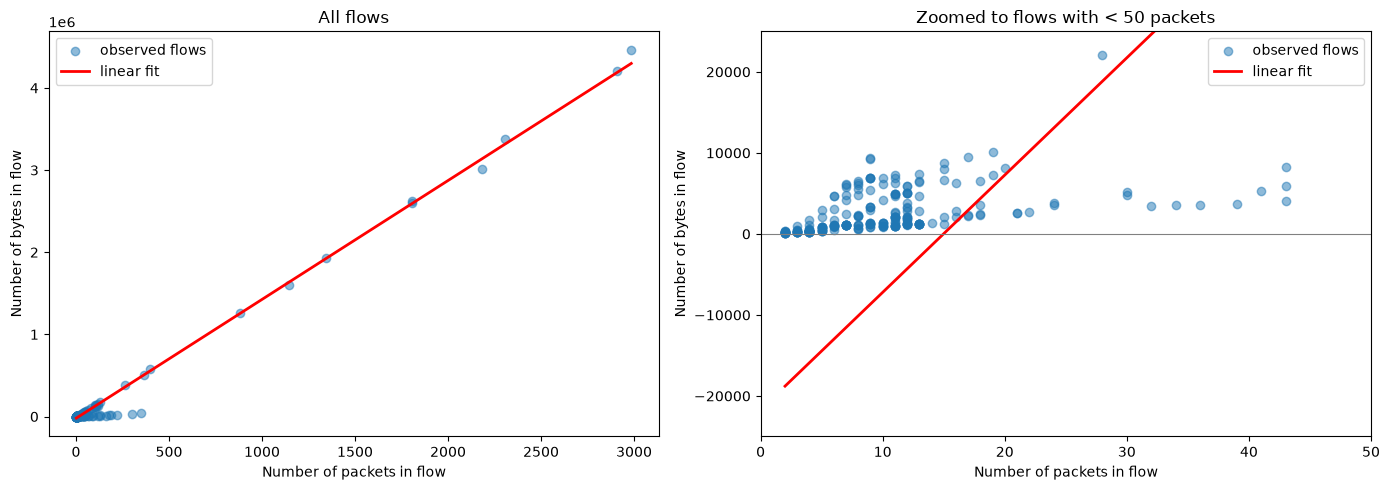

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sort by x so the fitted line plots as a single straight segment.
order = np.argsort(X[:, 0])

for ax, zoom in zip(axes, [False, True]):
    ax.scatter(X, y, alpha=0.5, label='observed flows')
    ax.plot(X[order, 0], y_hat[order], color='red', linewidth=2, label='linear fit')
    ax.set_xlabel('Number of packets in flow')
    ax.set_ylabel('Number of bytes in flow')
    ax.legend()
    if zoom:
        # Almost every flow is tiny, so zoom in on the bulk of the data.
        ax.set_xlim(0, 50)
        ax.set_ylim(-25000, 25000)
        ax.axhline(0, color='gray', linewidth=0.8)
        ax.set_title('Zoomed to flows with < 50 packets')
    else:
        ax.set_title('All flows')

plt.tight_layout()
plt.show()

Across the full range the fit looks excellent ($R^2 \approx 0.99$): bytes really do grow linearly
with packets, at roughly 1447 bytes per packet, which is close to a full-size Ethernet frame.

But that number is almost entirely determined by the dozen or so very large flows on the right.
The zoomed panel shows the problem: the median flow has only 11 packets and 2 KB, yet the fitted
line has an intercept of about **-21,700 bytes**, so it predicts a *negative* number of bytes for
every flow shorter than ~15 packets. There is also a visible group of flows near 300 packets that
carry almost no bytes---long exchanges of tiny packets---which the model misses completely, because
packet count alone says nothing about packet *size*.

So the residual error is dominated by the few huge flows (RMSE ~51 KB, larger than most flows in the
trace), while the fit is systematically wrong in relative terms for the hundreds of small flows.

### Evaluation: Error Computation

You can compute how well your manual fit is by computing the error, in terms of residual sum of squares.

In [7]:
residuals = y - y_hat

rss = np.sum(residuals ** 2)          # residual sum of squares
mse = np.mean(residuals ** 2)         # mean squared error
rmse = np.sqrt(mse)

print(f'RSS:  {rss:,.2f}')
print(f'MSE:  {mse:,.2f}')
print(f'RMSE: {rmse:,.2f} bytes')
print(f'R^2:  {model.score(X, y):.4f}')

RSS:  756,516,822,104.06
MSE:  2,599,714,165.31
RMSE: 50,987.39 bytes
R^2:  0.9903


## Part 2: Polynomial Basis Expansion

Recall that one of the benefits of a polynomial feature expansion is that it is possible to fit a linear model to a resulting polynomial expansion of the features.

We will do that below.  Let's first create the regular features and then the polynomial expansion. You will need the `PolynomialFeatures` library from `sklearn.preprocessing`, as well as the `fit_transform` function to generate your feature expansion.

Train the linear regression model on the expanded set of features, and generate a new set of predictions, `y_hat_poly`.

In [8]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)        # same X as Part 1: features[['num_pkts']]

model_poly = linear_model.LinearRegression().fit(X_poly, y)
y_hat_poly = model_poly.predict(X_poly)

Visualize your results again. What do you notice about the predicted values?

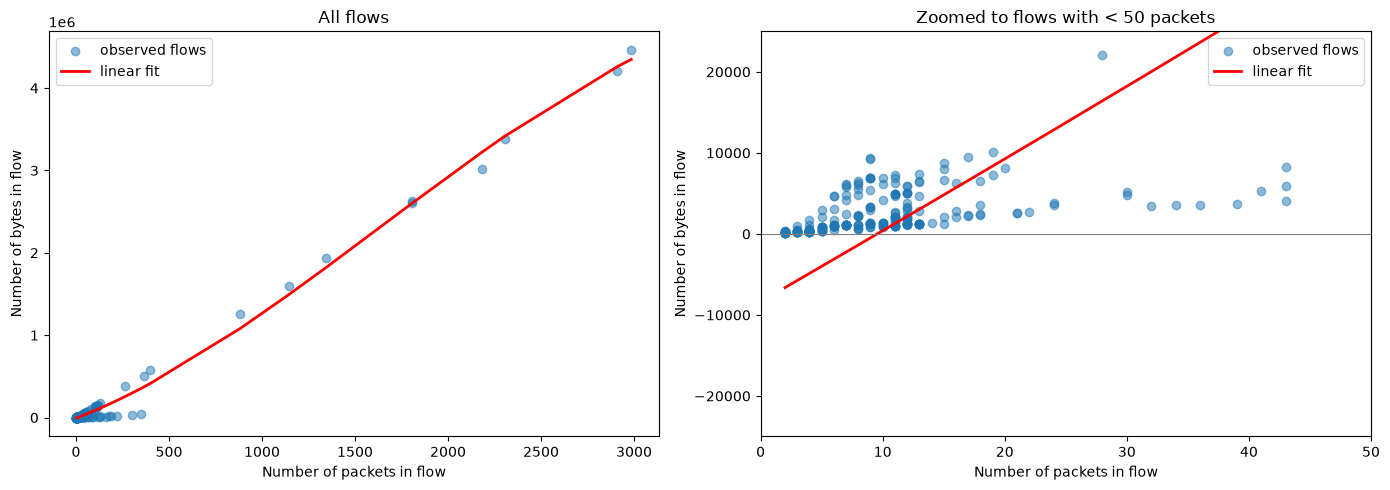

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sort by x so the fitted line plots as a single straight segment.
order = np.argsort(X[:, 0])

for ax, zoom in zip(axes, [False, True]):
    ax.scatter(X, y, alpha=0.5, label='observed flows')
    ax.plot(X[order, 0], y_hat_poly[order], color='red', linewidth=2, label='linear fit')
    ax.set_xlabel('Number of packets in flow')
    ax.set_ylabel('Number of bytes in flow')
    ax.legend()
    if zoom:
        # Almost every flow is tiny, so zoom in on the bulk of the data.
        ax.set_xlim(0, 50)
        ax.set_ylim(-25000, 25000)
        ax.axhline(0, color='gray', linewidth=0.8)
        ax.set_title('Zoomed to flows with < 50 packets')
    else:
        ax.set_title('All flows')

plt.tight_layout()
plt.show()

Evaluate your error once again. What happened to overall mean squared error?

In [10]:
residuals = y - y_hat_poly

rss = np.sum(residuals ** 2)          # residual sum of squares
mse = np.mean(residuals ** 2)         # mean squared error
rmse = np.sqrt(mse)

print(f'RSS:  {rss:,.2f}')
print(f'MSE:  {mse:,.2f}')
print(f'RMSE: {rmse:,.2f} bytes')
print(f'R^2:  {model_poly.score(X_poly, y):.4f}')

RSS:  516,992,786,027.96
MSE:  1,776,607,512.12
RMSE: 42,149.82 bytes
R^2:  0.9933


## Part 3: Exploring Relationships between Other Features

In the earlier parts of this hands-on, we explored simple relationship between features and outcome variables. You can extend your analysis by exploring other relationships, such as the relationships between one or more of the features already output from `netml`.

Here we keep the same target (`num_bytes`) but give the model a second feature, `mean_pkt_size`,
and apply a degree-2 polynomial expansion. The expansion now generates not just powers
($x_0^2$, $x_1^2$) but an **interaction term** $x_0 x_1$ --- and that turns out to matter a lot.

In [11]:
X_multi = features[['num_pkts', 'mean_pkt_size']].values

poly2 = PolynomialFeatures(degree=2)
X_multi_poly = poly2.fit_transform(X_multi)

model_multi = linear_model.LinearRegression().fit(X_multi_poly, y)
y_hat_multi = model_multi.predict(X_multi_poly)

# Which of the expanded terms did the model actually use?
terms = poly2.get_feature_names_out(['num_pkts', 'mean_pkt_size'])
print(pd.DataFrame({'term': terms, 'coefficient': model_multi.coef_.round(6)}).to_string(index=False))
print(f'\nintercept: {model_multi.intercept_:.6f}')

                  term  coefficient
                     1        0.000
              num_pkts       -0.000
         mean_pkt_size       -0.000
            num_pkts^2       -0.000
num_pkts mean_pkt_size        1.000
       mean_pkt_size^2        0.000

intercept: -0.000000


In [12]:
residuals_multi = y - y_hat_multi

print(f'RSS:  {np.sum(residuals_multi ** 2):,.2e}')
print(f'MSE:  {np.mean(residuals_multi ** 2):,.2e}')
print(f'R^2:  {model_multi.score(X_multi_poly, y):.10f}')
print(f'largest single residual: {np.max(np.abs(residuals_multi)):.2e} bytes')

# For comparison, the two models from Parts 1 and 2:
print(f'\nPart 1 (linear, num_pkts)      MSE: {np.mean((y - y_hat) ** 2):,.2e}')
print(f'Part 2 (degree 3, num_pkts)    MSE: {np.mean((y - y_hat_poly) ** 2):,.2e}')
print(f'Part 3 (degree 2, 2 features)  MSE: {np.mean(residuals_multi ** 2):,.2e}')

RSS:  1.19e-17
MSE:  4.10e-20
R^2:  1.0000000000
largest single residual: 1.86e-09 bytes

Part 1 (linear, num_pkts)      MSE: 2.60e+09
Part 2 (degree 3, num_pkts)    MSE: 1.78e+09
Part 3 (degree 2, 2 features)  MSE: 4.10e-20


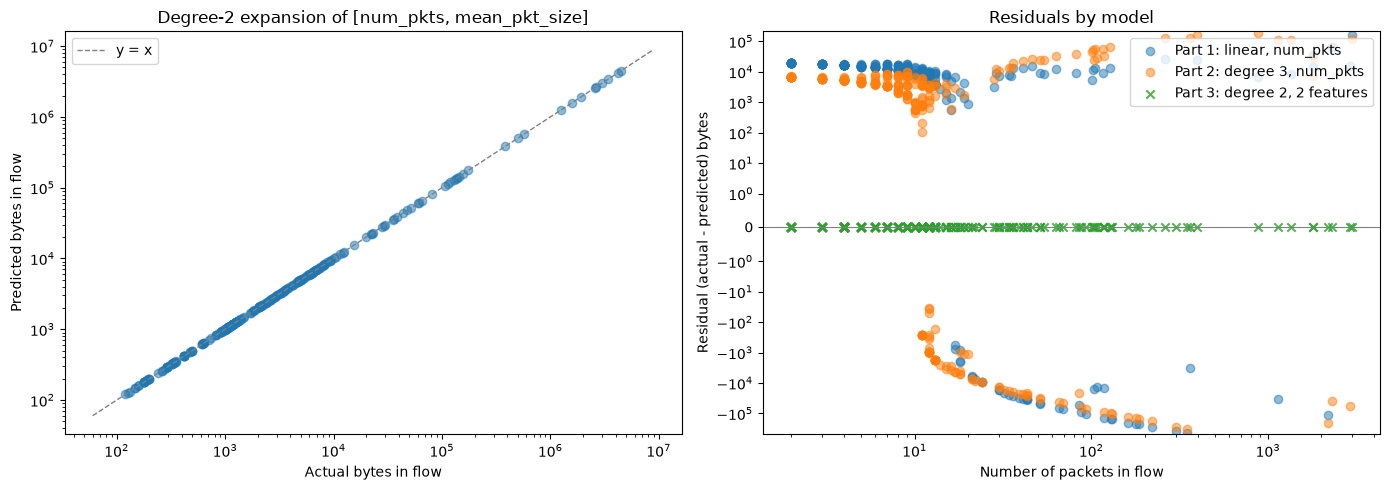

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: predicted vs. actual. A perfect model puts every point on the diagonal.
axes[0].scatter(y, y_hat_multi, alpha=0.5)
lims = [y.min() * 0.5, y.max() * 2]
axes[0].plot(lims, lims, color='gray', linestyle='--', linewidth=1, label='y = x')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Actual bytes in flow')
axes[0].set_ylabel('Predicted bytes in flow')
axes[0].set_title('Degree-2 expansion of [num_pkts, mean_pkt_size]')
axes[0].legend()

# Right: residuals from all three models. symlog handles the huge dynamic range
# and the negative residuals together.
axes[1].scatter(features['num_pkts'], y - y_hat, alpha=0.5, label='Part 1: linear, num_pkts')
axes[1].scatter(features['num_pkts'], y - y_hat_poly, alpha=0.5, label='Part 2: degree 3, num_pkts')
axes[1].scatter(features['num_pkts'], residuals_multi, alpha=0.8, marker='x',
                label='Part 3: degree 2, 2 features')
axes[1].axhline(0, color='gray', linewidth=0.8)
axes[1].set_xscale('log')
axes[1].set_yscale('symlog', linthresh=1)
axes[1].set_xlabel('Number of packets in flow')
axes[1].set_ylabel('Residual (actual - predicted) bytes')
axes[1].set_title('Residuals by model')
axes[1].legend()

plt.tight_layout()
plt.show()

**The model fits perfectly --- and that is the interesting result, not a good one.**

$R^2 = 1.0$, and the residuals are on the order of $10^{-9}$ bytes, which is floating-point noise
rather than error. The coefficient table says exactly why: every coefficient is zero except the
interaction term `num_pkts mean_pkt_size`, which gets a coefficient of **1.0**, and the intercept
is 0. The model has discovered the definition

$$\text{num\_bytes} = \text{num\_pkts} \times \text{mean\_pkt\_size}$$

which is how `netml` computed `mean_pkt_size` in the first place (`num_bytes / num_pkts`). Nothing
about the network was learned; an algebraic identity was recovered.

This is a clean illustration of two things at once:

1. **What basis expansion actually buys you.** Powers of a single feature ($x^2$, $x^3$) only let
   the curve bend. The *interaction* term lets the model express that two features combine
   multiplicatively --- which no amount of degree-3 expansion on `num_pkts` alone could do. Part 2
   at degree 3 was still at MSE $\approx 1.8 \times 10^9$; the right feature pairing took it to zero.

2. **Target leakage.** A feature derived from the target will hand you a perfect score that
   collapses the moment you use the model for anything. If `mean_pkt_size` were available at
   prediction time, you would not need to predict `num_bytes` --- you could just multiply. The same
   trap is present elsewhere in this feature set: `bytes_rate` $\times$ `duration` is also exactly
   `num_bytes`.

A perfect training score is a signal to go looking for leakage, not a result to report. An honest
version of this exercise would predict something not algebraically determined by the inputs --- for
example flow `duration` from `num_pkts` and `mean_pkt_size`, where the answer genuinely depends on
network behavior rather than on arithmetic.

## Bonus: Reducing Error on Test Set

In the above example, we used a polynomial basis expansion to reduce the error on the training set. But, we have no test set, so it is difficult to tell whether the model above is overfit to the training data.

In order for us to tell whether this model is a good fit, we need to test it on data that the model has not yet seen. This requires splitting the data into a training set and a test set.

A typical split between training data and test data might be 80% training data, 20% test data. You can also perform this process repeatedly and average the results. This process is called **cross-validation**.

### Part 1

1. Take a packet trace using wireshark and load it into the notebook.
2. Perform a simple linear regression fit and a fit with basis expansion (same as above), comparing errors.

The first two steps are the same as above, but you might try doing this for a larger sample so that your network traffic has more flows (i.e., data points).

### Part 2

3. Use functions from sklearn to split the data into training and testing. (train_test_split, or sklearn's CV function).
4. How does model accuracy compare for different polynomial basis expansions? (n=1, 2, 3, ?) At what point is the model overfit?
5. Can you experiment with a regularization parameter to control or reduce overfitting?